In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print("Shape:", df.shape)

df.info()

df.describe()

df.isnull().sum()

Shape: (7043, 21)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   s

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [4]:
# Convert TotalCharges to numeric if present
if 'TotalCharges' in df.columns:
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop missing values
df.dropna(inplace=True)

# Remove duplicates if any
df.drop_duplicates(inplace=True)

In [5]:
df['Churn_Flag'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

In [6]:
churn_rate = df['Churn_Flag'].mean() * 100
print(f"Overall Churn Rate: {churn_rate:.2f}%")

Overall Churn Rate: 26.58%


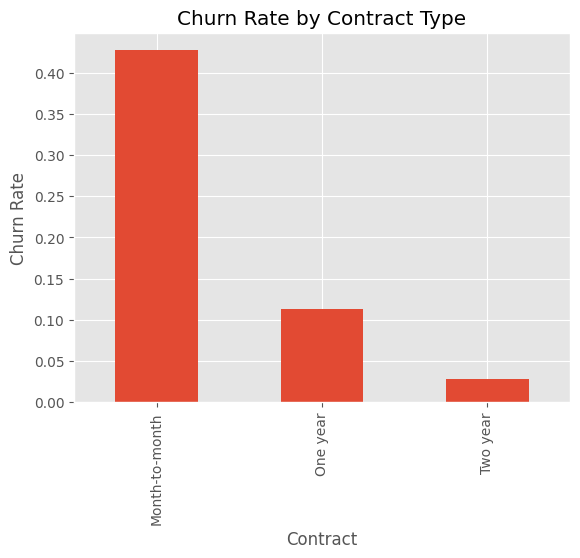

In [7]:
contract_churn = df.groupby('Contract')['Churn_Flag'].mean()

contract_churn.plot(kind='bar')
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate")
plt.show()

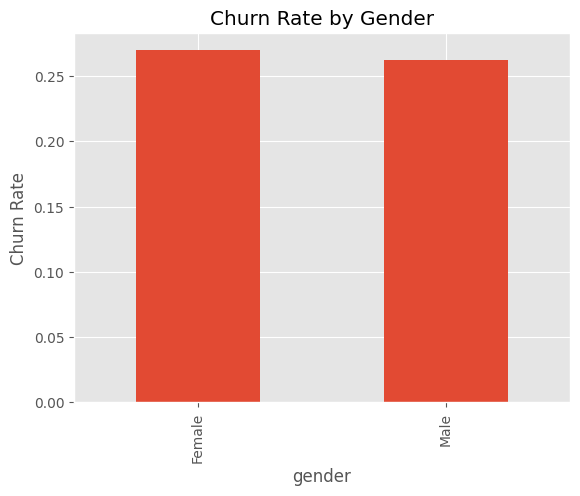

In [8]:
gender_churn = df.groupby('gender')['Churn_Flag'].mean()

gender_churn.plot(kind='bar')
plt.title("Churn Rate by Gender")
plt.ylabel("Churn Rate")
plt.show()

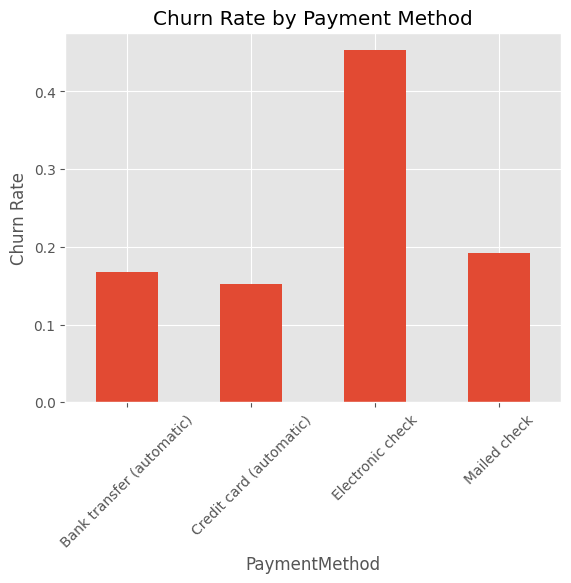

In [9]:
payment_churn = df.groupby('PaymentMethod')['Churn_Flag'].mean()

payment_churn.plot(kind='bar')
plt.title("Churn Rate by Payment Method")
plt.ylabel("Churn Rate")
plt.xticks(rotation=45)
plt.show()

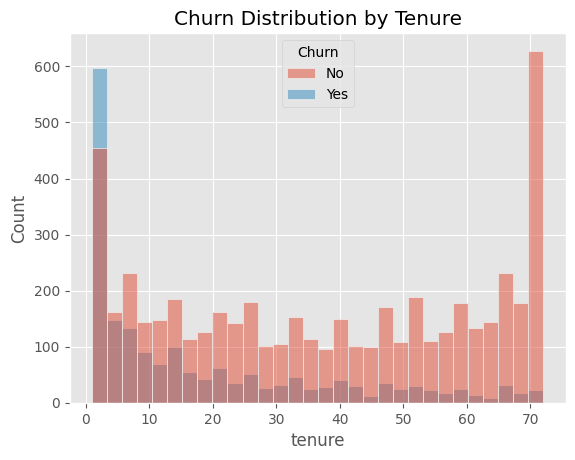

In [10]:
sns.histplot(data=df, x='tenure', hue='Churn', bins=30)
plt.title("Churn Distribution by Tenure")
plt.show()

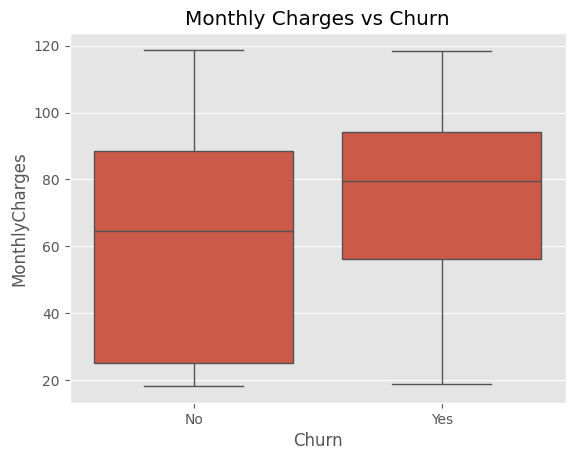

In [11]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

In [12]:
avg_tenure = df['tenure'].mean()
avg_monthly = df['MonthlyCharges'].mean()

print(f"Average Tenure: {avg_tenure:.2f}")
print(f"Average Monthly Charges: {avg_monthly:.2f}")

Average Tenure: 32.42
Average Monthly Charges: 64.80


In [13]:
avg_tenure = df['tenure'].mean()
avg_monthly = df['MonthlyCharges'].mean()

print(f"Average Tenure: {avg_tenure:.2f}")
print(f"Average Monthly Charges: {avg_monthly:.2f}")

Average Tenure: 32.42
Average Monthly Charges: 64.80


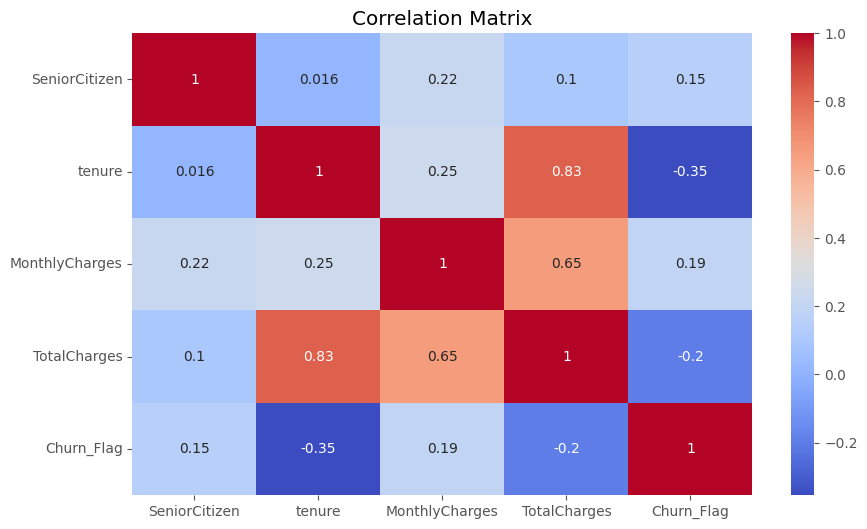

In [14]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

1. Month-to-month contract customers show the highest churn rate.
2. Customers with low tenure are more likely to churn.
3. Higher monthly charges slightly increase churn probability.
4. Long-term contract customers have better retention.
5. Payment method impacts churn behavior.

1. Offer discounts on yearly/long-term plans.
2. Improve onboarding experience for new customers.
3. Target high-churn segments with personalized offers.
4. Introduce loyalty programs for long-term users.
5. Monitor customers with high monthly charges.